# Final Model Training on Engineered Dataset

Models in this notebook:
1. XGBoost Regressor (tuned, full feature set)
2. Polynomial Regression (tuned, top-7 feature set)
3. Multiple Linear Regression (tuned, top-7 feature set)
4. Stacking Regressor (tuned, full feature set)

Datasets:
- `Dataset/train_data_feature_engineered_final.csv` (full feature set)
- `Dataset/train_data_top7_linear_models.csv` (top-7 feature set for polynomial and multiple linear models)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import TargetEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [17]:
df_full = pd.read_csv('Dataset/train_data_feature_engineered_final.csv')
df_top7 = pd.read_csv('Dataset/train_data_top7_linear_models.csv')
target = 'RecommendationCount'

cat_cols_full = [c for c in ['PriceCurrency', 'DRMNotice', 'ExtUserAcctNotice'] if c in df_full.columns]
num_cols_full = [c for c in df_full.columns if c not in cat_cols_full + [target]]

X_full = df_full[cat_cols_full + num_cols_full].copy()
y = pd.to_numeric(df_full[target], errors='coerce').fillna(0)

top7_feature_cols = [c for c in df_top7.columns if c != target]
X_top7 = df_top7[top7_feature_cols].copy()
y_top7 = pd.to_numeric(df_top7[target], errors='coerce').fillna(0)

if len(df_full) != len(df_top7):
    raise ValueError('Full and top7 datasets have different row counts. Regenerate preprocessing outputs first.')

split_idx = np.arange(len(df_full))
idx_train, idx_test = train_test_split(split_idx, test_size=0.2, random_state=42)

X_train_full = X_full.iloc[idx_train].copy()
X_test_full = X_full.iloc[idx_test].copy()
y_train = y.iloc[idx_train].copy()
y_test = y.iloc[idx_test].copy()

X_train_top7 = X_top7.iloc[idx_train].copy()
X_test_top7 = X_top7.iloc[idx_test].copy()
y_train_top7 = y_top7.iloc[idx_train].copy()
y_test_top7 = y_top7.iloc[idx_test].copy()

print('Full train/test shapes:', X_train_full.shape, X_test_full.shape)
print('Top7 train/test shapes:', X_train_top7.shape, X_test_top7.shape)
print('Target skew (full):', round(y.skew(), 2))
print('Top7 features:', top7_feature_cols)

Full train/test shapes: (9085, 103) (2272, 103)
Top7 train/test shapes: (9085, 7) (2272, 7)
Target skew (full): 68.01
Top7 features: ['SteamSpyPlayersEstimate', 'SteamSpyPlayersEstimate_log', 'DLCCount_log', 'PriceFinal_log', 'PCReqsHaveMin', 'PriceCurrency', 'PublisherCountCat']


In [18]:
# Encode full-dataset categoricals for XGBoost/stacking
if cat_cols_full:
    encoder_full = TargetEncoder(target_type='continuous')
    X_train_full_cat = pd.DataFrame(
        encoder_full.fit_transform(X_train_full[cat_cols_full], y_train),
        columns=cat_cols_full, index=X_train_full.index,
    )
    X_test_full_cat = pd.DataFrame(
        encoder_full.transform(X_test_full[cat_cols_full]),
        columns=cat_cols_full, index=X_test_full.index,
    )
else:
    X_train_full_cat = pd.DataFrame(index=X_train_full.index)
    X_test_full_cat = pd.DataFrame(index=X_test_full.index)

X_train_full_enc = pd.concat([X_train_full_cat, X_train_full[num_cols_full]], axis=1)
X_test_full_enc = pd.concat([X_test_full_cat, X_test_full[num_cols_full]], axis=1)

# Encode top-7 categoricals (if any) for linear/polynomial models
top7_cat_cols = X_train_top7.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
top7_num_cols = [c for c in X_train_top7.columns if c not in top7_cat_cols]

if top7_cat_cols:
    encoder_top7 = TargetEncoder(target_type='continuous')
    X_train_top7_cat = pd.DataFrame(
        encoder_top7.fit_transform(X_train_top7[top7_cat_cols], y_train_top7),
        columns=top7_cat_cols, index=X_train_top7.index,
    )
    X_test_top7_cat = pd.DataFrame(
        encoder_top7.transform(X_test_top7[top7_cat_cols]),
        columns=top7_cat_cols, index=X_test_top7.index,
    )
else:
    X_train_top7_cat = pd.DataFrame(index=X_train_top7.index)
    X_test_top7_cat = pd.DataFrame(index=X_test_top7.index)

X_train_top7_enc = pd.concat([X_train_top7_cat, X_train_top7[top7_num_cols]], axis=1)
X_test_top7_enc = pd.concat([X_test_top7_cat, X_test_top7[top7_num_cols]], axis=1)

# Force numeric matrices and fill potential NaN values for model compatibility
X_train_full_enc = X_train_full_enc.apply(pd.to_numeric, errors='coerce')
X_test_full_enc = X_test_full_enc.apply(pd.to_numeric, errors='coerce')
full_medians = X_train_full_enc.median(numeric_only=True)
X_train_full_enc = X_train_full_enc.fillna(full_medians).fillna(0)
X_test_full_enc = X_test_full_enc.fillna(full_medians).fillna(0)

X_train_top7_enc = X_train_top7_enc.apply(pd.to_numeric, errors='coerce')
X_test_top7_enc = X_test_top7_enc.apply(pd.to_numeric, errors='coerce')
top7_medians = X_train_top7_enc.median(numeric_only=True)
X_train_top7_enc = X_train_top7_enc.fillna(top7_medians).fillna(0)
X_test_top7_enc = X_test_top7_enc.fillna(top7_medians).fillna(0)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_train_top7_log = np.log1p(y_train_top7)
y_test_top7_log = np.log1p(y_test_top7)

print('Encoded full-train shape:', X_train_full_enc.shape)
print('Encoded top7-train shape:', X_train_top7_enc.shape)
print('Top7 categorical columns encoded:', top7_cat_cols)

Encoded full-train shape: (9085, 103)
Encoded top7-train shape: (9085, 7)
Top7 categorical columns encoded: ['PriceCurrency']


In [19]:
results = []
tuning_summary = []

def evaluate_model(name, feature_set, model, Xtr, Xte, ytr_log, yte, yte_log):
    model.fit(Xtr, ytr_log)
    pred_log = model.predict(Xte)
    pred = np.expm1(pred_log)
    rmse = mean_squared_error(yte, pred) ** 0.5
    results.append({
        'Model': name,
        'Feature Set': feature_set,
        'R2 (log space)': r2_score(yte_log, pred_log),
        'R2 (orig scale)': r2_score(yte, pred),
        'MAE (orig scale)': mean_absolute_error(yte, pred),
        'RMSE (orig scale)': rmse,
    })

def record_tuning(model_name, feature_set, search_obj):
    tuning_summary.append({
        'Model': model_name,
        'Feature Set': feature_set,
        'Best CV R2 (log)': round(search_obj.best_score_, 4),
        'Best Params': search_obj.best_params_,
    })

cv = KFold(n_splits=3, shuffle=True, random_state=42)

In [20]:
# 1) XGBoost on full feature set
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    )

xgb_param_dist = {
    'n_estimators': [400, 700, 1000, 1300],
    'learning_rate': [0.02, 0.03, 0.05, 0.07],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0.0, 0.1, 0.5],
    'reg_lambda': [1.0, 1.5, 2.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=12,
    scoring='r2',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    )
xgb_search.fit(X_train_full_enc, y_train_log)
record_tuning('XGBoost Regressor', 'full', xgb_search)
evaluate_model(
    'XGBoost Regressor (tuned)',
    'full',
    xgb_search.best_estimator_,
    X_train_full_enc,
    X_test_full_enc,
    y_train_log,
    y_test,
    y_test_log,
    )

# 2) Multiple Linear Regression on top-7 feature set
lin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression()),
])

lin_param_grid = {
    'linreg__fit_intercept': [True, False],
    'linreg__positive': [False, True],
}

lin_search = GridSearchCV(
    estimator=lin_pipeline,
    param_grid=lin_param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    )
lin_search.fit(X_train_top7_enc, y_train_top7_log)
record_tuning('Multiple Linear Regression', 'top7', lin_search)
evaluate_model(
    'Multiple Linear Regression (tuned)',
    'top7',
    lin_search.best_estimator_,
    X_train_top7_enc,
    X_test_top7_enc,
    y_train_top7_log,
    y_test_top7,
    y_test_top7_log,
    )

# 3) Polynomial Regression (Ridge) on top-7 feature set
poly_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge(random_state=42)),
])

poly_param_grid = {
    'poly__degree': [2, 3],
    'ridge__alpha': [0.1, 1.0, 5.0, 10.0, 20.0],
}

poly_search = GridSearchCV(
    estimator=poly_pipeline,
    param_grid=poly_param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    )
poly_search.fit(X_train_top7_enc, y_train_top7_log)
record_tuning('Polynomial Regression', 'top7', poly_search)
evaluate_model(
    'Polynomial Regression (tuned)',
    'top7',
    poly_search.best_estimator_,
    X_train_top7_enc,
    X_test_top7_enc,
    y_train_top7_log,
    y_test_top7,
    y_test_top7_log,
    )

# 4) Stacking on full feature set
stack_base = StackingRegressor(
    estimators=[
        ('xgb', XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
        )),
        ('rf', RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
        )),
        ('ridge', Ridge()),
    ],
    final_estimator=Ridge(),
    n_jobs=-1,
    passthrough=True,
    )

stack_param_dist = {
    'xgb__n_estimators': [250, 500, 800],
    'xgb__learning_rate': [0.03, 0.05, 0.07],
    'xgb__max_depth': [4, 6, 8],
    'xgb__subsample': [0.8, 0.9, 1.0],
    'rf__n_estimators': [200, 400, 600],
    'rf__max_depth': [10, 14, 18, None],
    'final_estimator__alpha': [0.5, 1.0, 2.0, 5.0, 10.0],
}

stack_search = RandomizedSearchCV(
    estimator=stack_base,
    param_distributions=stack_param_dist,
    n_iter=8,
    scoring='r2',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    )
stack_search.fit(X_train_full_enc, y_train_log)
record_tuning('Stacking Regressor', 'full', stack_search)
evaluate_model(
    'Stacking Regressor (tuned)',
    'full',
    stack_search.best_estimator_,
    X_train_full_enc,
    X_test_full_enc,
    y_train_log,
    y_test,
    y_test_log,
    )

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/ebrahim/Projects/ML_Project/env/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1632770987008358e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/ebrahim/Projects/ML_Project/env/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.2143146013224564e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/ebrahim/Projects/ML_Project/env/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.4078546399631324e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/ebrahim/Projects/ML_Project/env/lib64/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1632770987008358e-16.
  ret

,Model,Feature Set,Best CV R2 (log),Best Params
0,XGBoost Regressor,full,0.8073,"{'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alp..."
1,Multiple Linear Regression,top7,0.4738,"{'linreg__fit_intercept': True, 'linreg__posit..."
2,Polynomial Regression,top7,0.7146,"{'poly__degree': 2, 'ridge__alpha': 5.0}"
3,Stacking Regressor,full,0.7990,"{'xgb__subsample': 0.8, 'xgb__n_estimators': 8..."


,Model,Feature Set,R2 (log space),R2 (orig scale),MAE (orig scale),RMSE (orig scale)
0,XGBoost Regressor (tuned),full,0.8149,6.262000e-01,5.000479e+02,3.568255e+03
1,Stacking Regressor (tuned),full,0.8121,2.936000e-01,6.601868e+02,4.905494e+03
2,Multiple Linear Regression (tuned),top7,0.5100,-1.304700e+00,1.118109e+03,8.860368e+03
3,Polynomial Regression (tuned),top7,0.7117,-1.472179e+16,1.485680e+10,7.081566e+11


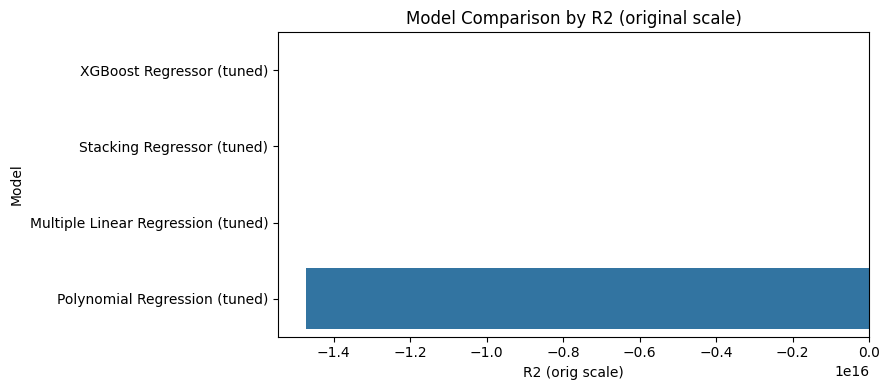

In [21]:
if tuning_summary:
    tuning_df = pd.DataFrame(tuning_summary)
    display(tuning_df)

results_df = pd.DataFrame(results).sort_values('R2 (orig scale)', ascending=False).reset_index(drop=True)
results_df = results_df.round(4)
display(results_df)

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x='R2 (orig scale)', y='Model')
plt.title('Model Comparison by R2 (original scale)')
plt.tight_layout()
plt.show()